<a href="https://colab.research.google.com/github/FaridRash/brain-ct-hemorrhage-segmentation/blob/main/Notebooks/Preprocess_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Google Drive mounting

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Unzip zipped image and mask folders

In [15]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/brain_ct_project/processed_npy.zip"
extract_path = "/content/processed_data"

# create folder if not exists
os.makedirs(extract_path, exist_ok=True)

# unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully to:", extract_path)

Unzipped successfully to: /content/processed_data


In [16]:
print(os.listdir("/content/processed_data"))
print(len(os.listdir("/content/processed_data/images")))
print(len(os.listdir("/content/processed_data/masks")))

['images', 'masks', 'labels.csv']
2814
2814


#Convert Segmentation to Classification

In [17]:
import os
import numpy as np
import pandas as pd

mask_dir = "/content/processed_data/masks"
image_dir = "/content/processed_data/images"

data = []

for mask_name in sorted(os.listdir(mask_dir)):

    mask_path = os.path.join(mask_dir, mask_name)
    image_path = os.path.join(image_dir, mask_name)

    # load mask (.npy)
    mask = np.load(mask_path)

    # label: 1 if any hemorrhage exists
    label = 1 if np.any(mask > 0) else 0

    data.append({
        "filename": mask_name,
        "image_path": image_path,
        "mask_path": mask_path,
        "label": label
    })

# create dataframe
df = pd.DataFrame(data)

# save CSV
csv_path = "/content/processed_data/labels.csv"
df.to_csv(csv_path, index=False)

print("Saved labels to:", csv_path)
print(df["label"].value_counts())

Saved labels to: /content/processed_data/labels.csv
label
0    2496
1     318
Name: count, dtype: int64


#Visualization

##Plot two random images

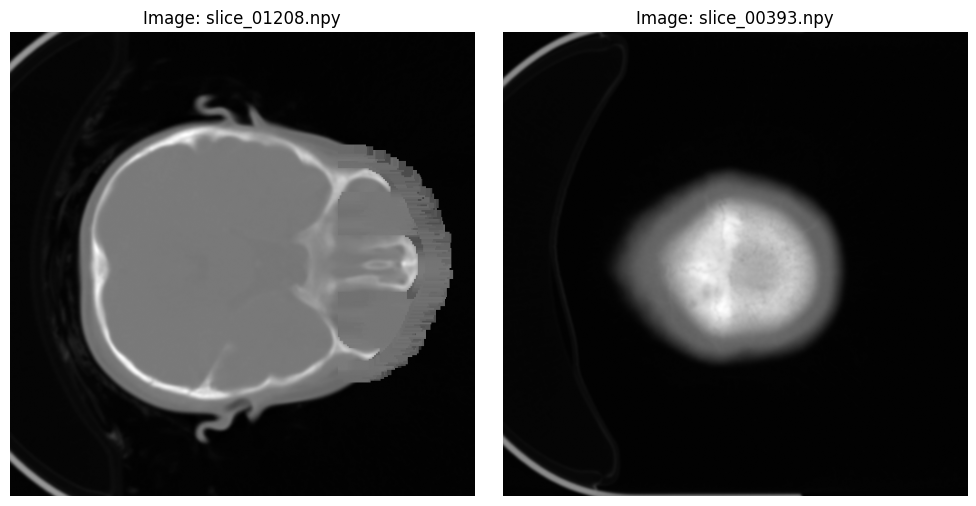

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
import random

image_dir = '/content/processed_data/images'
image_files = [f for f in os.listdir(image_dir) if f.endswith('.npy')]

if len(image_files) < 2:
    print("Not enough image files to plot two.")
elif len(image_files) > 0:
    # Select two random image files
    random_image_names = random.sample(image_files, 2)

    plt.figure(figsize=(10, 5))

    for i, img_name in enumerate(random_image_names):
        img_path = os.path.join(image_dir, img_name)
        image_data = np.load(img_path)

        plt.subplot(1, 2, i + 1)
        plt.imshow(image_data, cmap='gray')
        plt.title(f"Image: {img_name}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print(f"No .npy image files found in {image_dir}")

##Unique valuees of 5 images

In [19]:
import os
import numpy as np

image_dir = "/content/processed_data/images"

for i, fname in enumerate(sorted(os.listdir(image_dir))[:5]):  # first 5 images
    path = os.path.join(image_dir, fname)
    img = np.load(path)

    print(f"\n{fname}")
    print("Shape:", img.shape)
    print("Min:", img.min(), "Max:", img.max())
    print("Unique count:", len(np.unique(img)))


slice_00000.npy
Shape: (512, 512)
Min: -1022.0 Max: 2830.0
Unique count: 3497

slice_00001.npy
Shape: (512, 512)
Min: -1018.0 Max: 2914.0
Unique count: 3572

slice_00002.npy
Shape: (512, 512)
Min: -1014.0 Max: 2613.0
Unique count: 3183

slice_00003.npy
Shape: (512, 512)
Min: -1018.0 Max: 1968.0
Unique count: 2938

slice_00004.npy
Shape: (512, 512)
Min: -1018.0 Max: 1870.0
Unique count: 2790


##Data Distribution

Total valid samples: 2814
label
0    2496
1     318
Name: count, dtype: int64


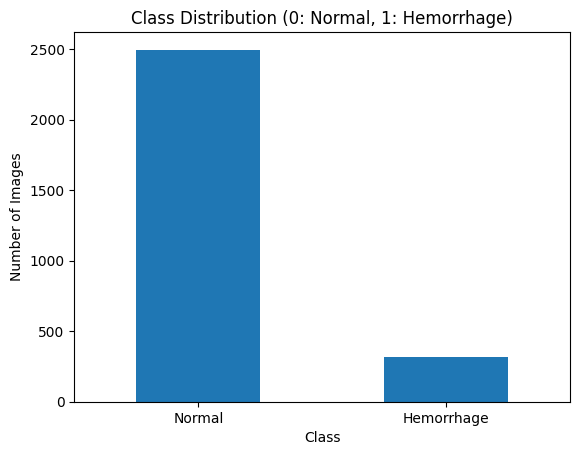

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# paths
csv_path = "/content/processed_data/labels.csv"
image_dir = "/content/processed_data/images"

# load labels
df = pd.read_csv(csv_path)

# ---- sanity check: match files ----
image_files = set(os.listdir(image_dir))
df = df[df["filename"].isin(image_files)]

print("Total valid samples:", len(df))
print(df["label"].value_counts())

# ---- plot distribution ----
counts = df["label"].value_counts().sort_index()

plt.figure()
counts.plot(kind="bar")

plt.title("Class Distribution (0: Normal, 1: Hemorrhage)")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks([0, 1], ["Normal", "Hemorrhage"], rotation=0)

plt.show()

#Data Filtering

##Air filtering

In [21]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

# ===== PATHS =====
image_dir = "/content/processed_data/images"
csv_path = "/content/processed_data/labels.csv"

output_image_dir = "/content/processed_data_filtered_air/images"
output_csv_path = "/content/processed_data_filtered_air/labels.csv"

os.makedirs(output_image_dir, exist_ok=True)

# ===== LOAD LABELS =====
df = pd.read_csv(csv_path)

filtered_data = []

removed_0 = 0
removed_1 = 0

# ===== AIR FILTER LOOP =====
for _, row in tqdm(df.iterrows(), total=len(df)):

    filename = row["filename"]
    label = row["label"]

    img_path = os.path.join(image_dir, filename)
    img = np.load(img_path).astype(np.float32)

    # ===== AIR RATIO =====
    air_ratio = np.mean(img < -900)

    # ===== CLASS-AWARE THRESHOLD =====
    if label == 0:
        remove = air_ratio > 0.9
    else:  # label == 1
        remove = air_ratio > 0.95

    # ===== KEEP OR REMOVE =====
    if not remove:
        np.save(os.path.join(output_image_dir, filename), img)
        filtered_data.append([filename, label])
    else:
        if label == 0:
            removed_0 += 1
        else:
            removed_1 += 1

# ===== SAVE NEW CSV =====
filtered_df = pd.DataFrame(filtered_data, columns=["filename", "label"])
filtered_df.to_csv(output_csv_path, index=False)

# ===== REPORT =====
print("Air filtering done\n")

print("Original dataset:")
print(df["label"].value_counts(), "\n")

print("Filtered dataset:")
print(filtered_df["label"].value_counts(), "\n")

print("Removed samples:")
print(f"Class 0 removed: {removed_0}")
print(f"Class 1 removed: {removed_1}")

100%|██████████| 2814/2814 [00:32<00:00, 86.56it/s]

Air filtering done

Original dataset:
label
0    2496
1     318
Name: count, dtype: int64 

Filtered dataset:
label
0    2326
1     318
Name: count, dtype: int64 

Removed samples:
Class 0 removed: 170
Class 1 removed: 0


##Undersampling

In [23]:
import os
import shutil
import pandas as pd
from tqdm import tqdm

# ===== PATHS =====
input_image_dir = "/content/processed_data_filtered_air/images"
input_csv_path = "/content/processed_data_filtered_air/labels.csv"

output_image_dir = "/content/processed_data_balanced/images"
output_csv_path = "/content/processed_data_balanced/labels.csv"

os.makedirs(output_image_dir, exist_ok=True)

# ===== LOAD DATA =====
df = pd.read_csv(input_csv_path)

# ===== SPLIT CLASSES =====
df_0 = df[df["label"] == 0]
df_1 = df[df["label"] == 1]

print("Before undersampling:")
print(df["label"].value_counts(), "\n")

# ===== SHUFFLE CLASS 0 =====
df_0 = df_0.sample(frac=1, random_state=42).reset_index(drop=True)

# ===== TARGET SIZE (adjust if needed) =====
target_0 = 900

df_0_sampled = df_0.iloc[:target_0]

# ===== COMBINE =====
df_final = pd.concat([df_0_sampled, df_1])
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

# ===== COPY FILES =====
for _, row in tqdm(df_final.iterrows(), total=len(df_final)):
    filename = row["filename"]

    src = os.path.join(input_image_dir, filename)
    dst = os.path.join(output_image_dir, filename)

    shutil.copy(src, dst)

# ===== SAVE CSV =====
df_final.to_csv(output_csv_path, index=False)

# ===== REPORT =====
print("\nAfter undersampling:")
print(df_final["label"].value_counts())

Before undersampling:
label
0    2326
1     318
Name: count, dtype: int64 



100%|██████████| 1218/1218 [00:15<00:00, 77.07it/s] 


After undersampling:
label
0    900
1    318
Name: count, dtype: int64


##Data visualization after filtering

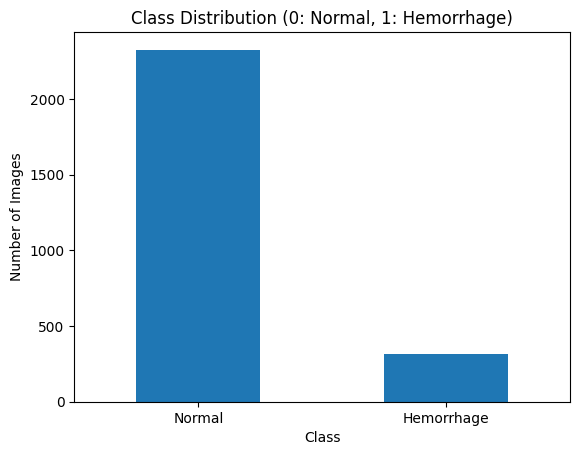

In [22]:
# ---- plot distribution ----
counts = filtered_df["label"].value_counts().sort_index()

plt.figure()
counts.plot(kind="bar")

plt.title("Class Distribution (0: Normal, 1: Hemorrhage)")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks([0, 1], ["Normal", "Hemorrhage"], rotation=0)

plt.show()

#Normalization

In [24]:
import os
import numpy as np
from tqdm import tqdm

# ===== PATHS =====
input_dir = "/content/processed_data_balanced/images"
output_dir = "/content/processed_data_balanced_windowed/images"

os.makedirs(output_dir, exist_ok=True)

# ===== WINDOW PARAMETERS (Brain Window) =====
WL = 40
WW = 80

lower = WL - (WW / 2)
upper = WL + (WW / 2)

print("Input folder:", input_dir)
print("Number of files:", len(os.listdir(input_dir)))

processed = 0
skipped = 0

# ===== LOOP =====
for img_name in tqdm(sorted(os.listdir(input_dir))):

    # ---- only process .npy ----
    if not img_name.endswith(".npy"):
        skipped += 1
        continue

    img_path = os.path.join(input_dir, img_name)

    try:
        # ---- load image ----
        img = np.load(img_path).astype(np.float32)

        # ---- windowing ----
        img = np.clip(img, lower, upper)

        # ---- normalize to 0–1 ----
        img = (img - lower) / (upper - lower)

        # ---- safety clamp (numerical stability) ----
        img = np.clip(img, 0.0, 1.0)

        # ---- save ----
        np.save(os.path.join(output_dir, img_name), img)

        processed += 1

    except Exception as e:
        print(f"Error processing {img_name}: {e}")
        skipped += 1

# ===== REPORT =====
print("\nDone: windowing + normalization applied")
print(f"Processed: {processed}")
print(f"Skipped: {skipped}")

Input folder: /content/processed_data_balanced/images
Number of files: 1218


100%|██████████| 1218/1218 [00:20<00:00, 60.86it/s]


Done: windowing + normalization applied
Processed: 1218
Skipped: 0


#Splitting

#Augmentation

#Save the final dataset to Google Drive

In [ ]:
import os
import shutil

source_base = "/content/drive/MyDrive/brain_ct_project/processed_png"
final_base = "/content/processed_png_final"

# remove if exists (to avoid conflicts)
if os.path.exists(final_base):
    shutil.rmtree(final_base)

# create new folder
os.makedirs(final_base, exist_ok=True)

print("Step 1 done.")

Step 1 done.


In [ ]:
# update source path
source_base = "/content/processed_data"

# copy images
shutil.copytree(
    os.path.join(source_base, "images"),
    os.path.join(final_base, "images")
)

# copy labels.csv
shutil.copy(
    os.path.join(source_base, "labels.csv"),
    os.path.join(final_base, "labels.csv")
)

print("Step 2 done.")

Step 2 done.


In [ ]:
import shutil

shutil.make_archive("/content/processed_png_final", 'zip', final_base)

print("Step 3 done — ZIP created.")

Step 3 done — ZIP created.


In [ ]:
shutil.move(
    "/content/processed_png_final.zip",
    "/content/drive/MyDrive/brain_ct_project/processed_png_final.zip"
)

print("Step 4 done — saved in Google Drive.")

Step 4 done — saved in Google Drive.


In [ ]:
import os

print(os.path.exists("/content/drive/MyDrive/brain_ct_project/processed_png_final.zip"))

True
